Starting Model Consistency Analysis...
Analyzing folder: ../outputs
--------------------------------------------------
OSS -> OSS: 0.774 (72/93)
OpenT -> OpenT: 0.659 (56/85)
OSS -> OpenT: 0.653 (62/95)
QwQ -> OpenT: 0.731 (68/93)
NRR -> OSS: 0.333 (27/81)
OSS -> DAPO: 0.582 (53/91)
OpenT -> OSS: 0.537 (44/82)
NRR -> DAPO: 0.216 (19/88)
OpenT -> DAPO: 0.536 (45/84)
OSS -> NRR: 0.435 (40/92)
QwQ -> OSS: 0.721 (62/86)
OSS -> QwQ: 0.699 (65/93)
QwQ -> DAPO: 0.761 (70/92)
NRR -> NRR: 0.622 (56/90)
OpenT -> NRR: 0.442 (38/86)
NRR -> QwQ: 0.286 (26/91)
OpenT -> QwQ: 0.500 (42/84)
QwQ -> NRR: 0.522 (47/90)
QwQ -> QwQ: 0.811 (73/90)
DAPO -> OSS: 0.713 (62/87)
DAPO -> DAPO: 0.891 (82/92)
DAPO -> NRR: 0.489 (43/88)
DAPO -> QwQ: 0.710 (66/93)
DAPO -> OpenT: 0.648 (59/91)
NRR -> OpenT: 0.455 (40/88)

Found 25 model pair combinations
--------------------------------------------------
Generating plots...
  Creating consistency heatmap...


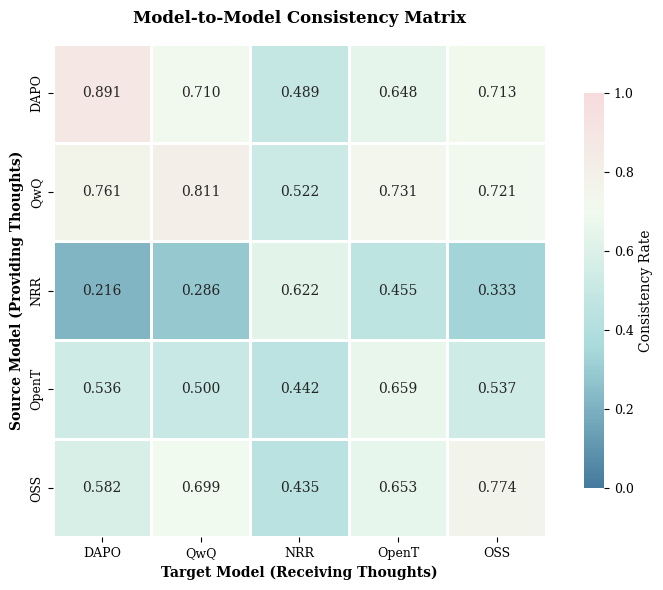

  Creating model comparison plot...


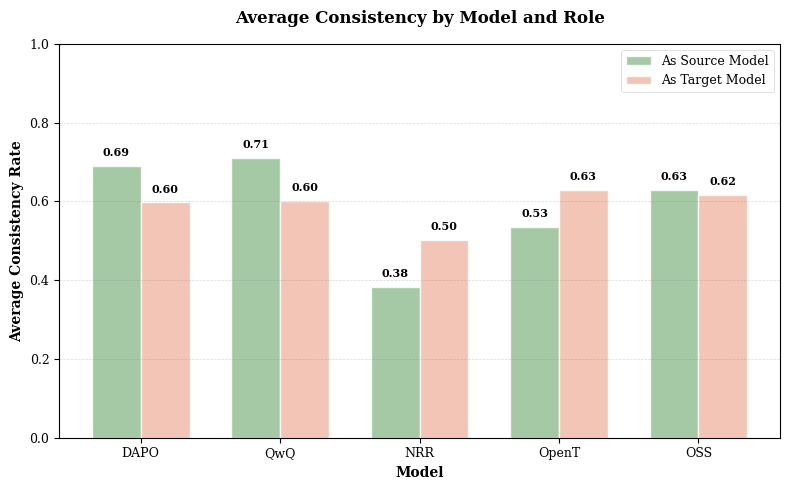

  Calculating pairwise consistency...
  Creating pairwise analysis plots...


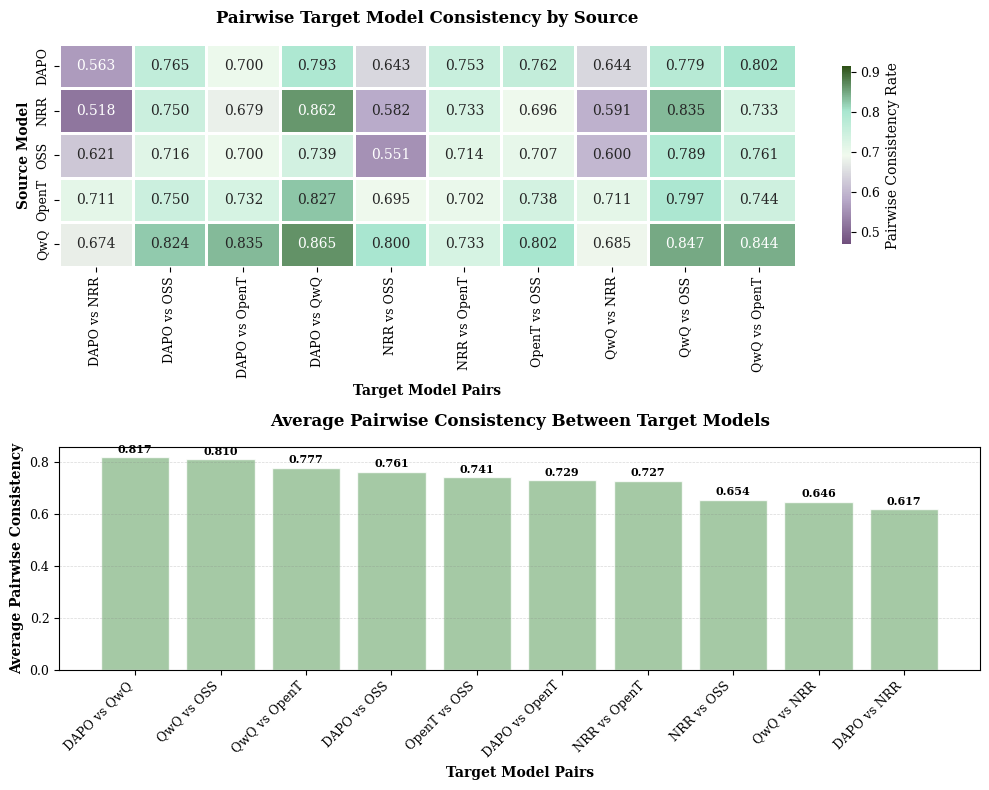


PAIRWISE TARGET MODEL CONSISTENCY
DAPO: DAPO vs OSS = 0.765 (65/85)
DAPO: NRR vs OSS = 0.643 (54/84)
DAPO: OSS vs QwQ = 0.779 (67/86)
DAPO: OSS vs OpenT = 0.762 (64/84)
DAPO: DAPO vs NRR = 0.563 (49/87)
DAPO: DAPO vs QwQ = 0.793 (73/92)
DAPO: DAPO vs OpenT = 0.700 (63/90)
DAPO: NRR vs QwQ = 0.644 (56/87)
DAPO: NRR vs OpenT = 0.753 (64/85)
DAPO: OpenT vs QwQ = 0.802 (73/91)
QwQ: OSS vs OpenT = 0.802 (69/86)
QwQ: DAPO vs OpenT = 0.835 (76/91)
QwQ: NRR vs OpenT = 0.733 (66/90)
QwQ: OpenT vs QwQ = 0.844 (76/90)
QwQ: DAPO vs OSS = 0.824 (70/85)
QwQ: NRR vs OSS = 0.800 (68/85)
QwQ: OSS vs QwQ = 0.847 (72/85)
QwQ: DAPO vs NRR = 0.674 (60/89)
QwQ: DAPO vs QwQ = 0.865 (77/89)
QwQ: NRR vs QwQ = 0.685 (61/89)
NRR: DAPO vs OSS = 0.750 (57/76)
NRR: NRR vs OSS = 0.582 (46/79)
NRR: OSS vs QwQ = 0.835 (66/79)
NRR: OSS vs OpenT = 0.696 (55/79)
NRR: DAPO vs NRR = 0.518 (44/85)
NRR: DAPO vs QwQ = 0.862 (75/87)
NRR: DAPO vs OpenT = 0.679 (57/84)
NRR: NRR vs QwQ = 0.591 (52/88)
NRR: NRR vs OpenT = 0.733 (

In [31]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for clean plots
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 100,
})

# Define pastel, paper-friendly color schemes
HEATMAP_COLORS = ['#457B9D', '#A8DADC', '#F1FAEE', '#F8D7DA', '#E63946']
HEATMAP_CMAP = LinearSegmentedColormap.from_list('pastel_heatmap', HEATMAP_COLORS)

PAIRWISE_COLORS = ['#6F4E7C', '#B8A9C9', '#F1FAEE', '#A8E6CF', '#2D5016']
PAIRWISE_CMAP = LinearSegmentedColormap.from_list('pastel_pairwise', PAIRWISE_COLORS)

BAR_COLORS = ['#8FBC8F', '#F0B7A4']  # Soft green and soft peach

def create_short_model_names():
    """Create mapping for short model names."""
    return {
        'openai_gpt-oss-20b': 'OSS',
        'BytedTsinghua-SIA_DAPO-Qwen-32B': 'DAPO', 
        'Qwen_QwQ-32B': 'QwQ',
        'open-thoughts_OpenThinker-7B': 'OpenT',
        'nvidia_Nemotron-Research-Reasoning-Qwen-1.5B': 'NRR'
    }

def parse_jsonl_file(filepath):
    """Parse a JSONL file and return list of data points."""
    data_points = []
    
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if line:
                    try:
                        data = json.loads(line)
                        data_points.append(data)
                    except json.JSONDecodeError as e:
                        print(f"Error parsing line {line_num} in {filepath}: {e}")
                        continue
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return []
    except Exception as e:
        print(f"Error reading file {filepath}: {e}")
        return []
    
    return data_points

def check_consistency(data_point):
    """Check if two models are consistent on a data point."""
    llm_answer = data_point.get("LLM Answer", "")
    target_answer = data_point.get("Target Answer", "")

    # Skip invalid responses
    invalid_patterns = ["not defined", "N/A", "does not match", "are not permitted"]
    if any(pattern in llm_answer for pattern in invalid_patterns) or \
       any(pattern in target_answer for pattern in invalid_patterns):
        return None
    
    # Exact match
    if llm_answer == target_answer:
        return 1
    
    # Both results are "Correct"
    result = data_point.get("Result", "")
    target_result = data_point.get("Target Result", "")
    if result == "Correct" and target_result == "Correct":
        return 1
    
    return 0

def extract_model_names(filename):
    """Extract source and target model names from filename."""
    pattern = r'(.+)_thoughts_to_(.+)_zero_shot_'
    match = re.match(pattern, filename)
    return (match.group(1), match.group(2)) if match else (None, None)

def calculate_consistency_matrix(folder_path):
    """Calculate consistency matrix for all model pairs."""
    if not os.path.exists(folder_path):
        print(f"Folder path does not exist: {folder_path}")
        return {}, [], {}
    
    consistency_data = {}
    model_names = set()
    data_by_source = {}
    
    jsonl_files = [f for f in os.listdir(folder_path) if f.endswith('.jsonl') and '_thoughts_to_' in f and 'without_answer' in f]
    
    if not jsonl_files:
        print("No JSONL files found matching the expected pattern.")
        return {}, [], {}
    
    for filename in jsonl_files:
        source_model, target_model = extract_model_names(filename)
        
        if source_model and target_model:
            model_names.add(source_model)
            model_names.add(target_model)
            
            filepath = os.path.join(folder_path, filename)
            data_points = parse_jsonl_file(filepath)
            
            if data_points:
                data_by_source[(source_model, target_model)] = data_points
                
                consistency_results = [check_consistency(dp) for dp in data_points]
                valid_results = [result for result in consistency_results if result is not None]
                
                if valid_results:
                    consistent_count = sum(valid_results)
                    total_count = len(valid_results)
                    consistency_rate = consistent_count / total_count
                    
                    consistency_data[(source_model, target_model)] = {
                        'consistency_rate': consistency_rate,
                        'consistent_count': consistent_count,
                        'total_count': total_count
                    }
                    
                    name_mapping = create_short_model_names()
                    short_source = name_mapping.get(source_model, source_model[:10])
                    short_target = name_mapping.get(target_model, target_model[:10])
                    print(f"{short_source} -> {short_target}: {consistency_rate:.3f} ({consistent_count}/{total_count})")
    
    return consistency_data, sorted(list(model_names)), data_by_source

def create_consistency_matrix(consistency_data, model_names):
    """Create a matrix for visualization."""
    n_models = len(model_names)
    matrix = np.zeros((n_models, n_models))
    model_to_idx = {model: idx for idx, model in enumerate(model_names)}
    
    for (source, target), data in consistency_data.items():
        if source in model_to_idx and target in model_to_idx:
            i = model_to_idx[source]
            j = model_to_idx[target]
            matrix[i, j] = data['consistency_rate']
    
    return matrix

def calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source):
    """Calculate pairwise consistency between target models for each source model."""
    pairwise_consistency = {}
    
    for source_model in model_names:
        targets = [target for (src, target) in consistency_data.keys() if src == source_model]
        
        if len(targets) < 2:
            continue
            
        for i in range(len(targets)):
            for j in range(i + 1, len(targets)):
                target_a = targets[i]
                target_b = targets[j]
                
                key_a = (source_model, target_a)
                key_b = (source_model, target_b)
                
                if key_a in data_by_source and key_b in data_by_source:
                    data_a = data_by_source[key_a]
                    data_b = data_by_source[key_b]
                    
                    consistent_pairs = 0
                    total_pairs = 0
                    
                    for idx in range(min(len(data_a), len(data_b))):
                        consistency_a = check_consistency(data_a[idx])
                        consistency_b = check_consistency(data_b[idx])
                        
                        if consistency_a is None or consistency_b is None:
                            continue
                        
                        total_pairs += 1
                        if consistency_a == consistency_b:
                            consistent_pairs += 1
                    
                    if total_pairs > 0:
                        pairwise_rate = consistent_pairs / total_pairs
                        pairwise_consistency[(source_model, target_a, target_b)] = {
                            'consistency_rate': pairwise_rate,
                            'consistent_pairs': consistent_pairs,
                            'total_pairs': total_pairs
                        }
    
    return pairwise_consistency

def plot_consistency_heatmap(consistency_data, model_names, save_plots=False, pdf_pages=None):
    """Create heatmap of consistency matrix."""
    fig, ax = plt.subplots(figsize=(8, 6))
    consistency_matrix = create_consistency_matrix(consistency_data, model_names)
    
    name_mapping = create_short_model_names()
    short_names = [name_mapping.get(name, name[:10]) for name in model_names]
    
    mask = consistency_matrix == 0
    sns.heatmap(consistency_matrix, 
                xticklabels=short_names, 
                yticklabels=short_names,
                annot=True, 
                fmt='.3f', 
                cmap=HEATMAP_CMAP,
                center=0.7,
                vmin=0.0, vmax=1.0,
                square=True,
                mask=mask,
                cbar_kws={'label': 'Consistency Rate', 'shrink': 0.8},
                linewidths=0.8,
                linecolor='white',
                ax=ax)
    
    ax.set_title('Model-to-Model Consistency Matrix', fontweight='bold', pad=15)
    ax.set_xlabel('Target Model (Receiving Thoughts)', fontweight='bold')
    ax.set_ylabel('Source Model (Providing Thoughts)', fontweight='bold')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig('consistency_heatmap.pdf', bbox_inches='tight', facecolor='white')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return consistency_matrix

def plot_model_comparison(consistency_data, model_names, save_plots=False, pdf_pages=None):
    """Create bar plot of average consistency by model."""
    fig, ax = plt.subplots(figsize=(8, 5))
    
    name_mapping = create_short_model_names()
    short_names = [name_mapping.get(name, name[:10]) for name in model_names]
    
    source_avg = defaultdict(list)
    target_avg = defaultdict(list)
    
    for (source, target), data in consistency_data.items():
        source_avg[source].append(data['consistency_rate'])
        target_avg[target].append(data['consistency_rate'])
    
    x = np.arange(len(model_names))
    width = 0.35
    
    source_values = [np.mean(source_avg[model]) if model in source_avg else 0 for model in model_names]
    target_values = [np.mean(target_avg[model]) if model in target_avg else 0 for model in model_names]
    
    bars1 = ax.bar(x - width/2, source_values, width, label='As Source Model', 
                   color=BAR_COLORS[0], alpha=0.8, edgecolor='white', linewidth=1)
    bars2 = ax.bar(x + width/2, target_values, width, label='As Target Model', 
                   color=BAR_COLORS[1], alpha=0.8, edgecolor='white', linewidth=1)
    
    ax.set_xlabel('Model', fontweight='bold')
    ax.set_ylabel('Average Consistency Rate', fontweight='bold')
    ax.set_title('Average Consistency by Model and Role', fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names)
    ax.legend(frameon=True, fancybox=True, shadow=False, facecolor='white')
    ax.grid(axis='y', alpha=0.3, linestyle='--', color='gray')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_by_model.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig('consistency_by_model.pdf', bbox_inches='tight', facecolor='white')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight', facecolor='white')
    plt.show()

def plot_pairwise_analysis(pairwise_consistency, save_plots=False, pdf_pages=None):
    """Create pairwise target model consistency visualizations."""
    if not pairwise_consistency:
        print("No pairwise consistency data available for visualization.")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    name_mapping = create_short_model_names()
    
    # Prepare data with short names
    target_pairs = []
    source_models = []
    pairwise_values = []
    
    for (source, target_a, target_b), data in pairwise_consistency.items():
        # Standardize pair names by sorting
        sorted_targets = sorted([target_a, target_b])
        short_a = name_mapping.get(sorted_targets[0], sorted_targets[0][:10])
        short_b = name_mapping.get(sorted_targets[1], sorted_targets[1][:10])
        pair_name = f"{short_a} vs {short_b}"
        
        target_pairs.append(pair_name)
        source_models.append(name_mapping.get(source, source[:10]))
        pairwise_values.append(data['consistency_rate'])
    
    pairwise_df = pd.DataFrame({
        'Source': source_models,
        'Target_Pair': target_pairs,
        'Consistency': pairwise_values
    })
    
    # Heatmap
    pivot_df = pairwise_df.pivot(index='Source', columns='Target_Pair', values='Consistency')
    
    if not pivot_df.empty:
        min_val = max(0.3, pivot_df.min().min() - 0.05)
        max_val = min(1.0, pivot_df.max().max() + 0.05)
    else:
        min_val, max_val = 0.3, 1.0
    
    mask = pivot_df.isna()
    
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap=PAIRWISE_CMAP, 
               ax=axes[0], cbar_kws={'label': 'Pairwise Consistency Rate', 'shrink': 0.8},
               vmin=min_val, vmax=max_val, linewidths=0.8, linecolor='white',
               mask=mask, cbar=True)
    
    axes[0].set_title('Pairwise Target Model Consistency by Source', fontweight='bold', pad=15)
    axes[0].set_xlabel('Target Model Pairs', fontweight='bold')
    axes[0].set_ylabel('Source Model', fontweight='bold')
    
    # Bar plot
    avg_pairwise = pairwise_df.groupby('Target_Pair')['Consistency'].mean().sort_values(ascending=False)
    
    bars = axes[1].bar(range(len(avg_pairwise)), avg_pairwise.values, 
                       color=BAR_COLORS[0], alpha=0.8, edgecolor='white', linewidth=1)
    axes[1].set_xlabel('Target Model Pairs', fontweight='bold')
    axes[1].set_ylabel('Average Pairwise Consistency', fontweight='bold')
    axes[1].set_title('Average Pairwise Consistency Between Target Models', fontweight='bold', pad=15)
    axes[1].set_xticks(range(len(avg_pairwise)))
    axes[1].set_xticklabels(avg_pairwise.index, rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3, linestyle='--', color='gray')
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('pairwise_target_consistency.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig('pairwise_target_consistency.pdf', bbox_inches='tight', facecolor='white')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight', facecolor='white')
    plt.show()

def print_summary_statistics(consistency_data, pairwise_consistency):
    """Print summary statistics with short model names."""
    name_mapping = create_short_model_names()
    
    print("\n" + "="*60)
    print("PAIRWISE TARGET MODEL CONSISTENCY")
    print("="*60)
    
    pairwise_values = []
    for (source, target_a, target_b), data in pairwise_consistency.items():
        short_source = name_mapping.get(source, source[:10])
        short_a = name_mapping.get(target_a, target_a[:10])
        short_b = name_mapping.get(target_b, target_b[:10])
        
        sorted_short_targets = sorted([short_a, short_b])
        
        print(f"{short_source}: {sorted_short_targets[0]} vs {sorted_short_targets[1]} = {data['consistency_rate']:.3f} "
              f"({data['consistent_pairs']}/{data['total_pairs']})")
        pairwise_values.append(data['consistency_rate'])
    
    if pairwise_values:
        print(f"\nPairwise Analysis Summary:")
        print(f"  Mean: {np.mean(pairwise_values):.3f}")
        print(f"  Median: {np.median(pairwise_values):.3f}")
        print(f"  Std Dev: {np.std(pairwise_values):.3f}")
    
    print("\n" + "="*60)
    print("OVERALL CONSISTENCY ANALYSIS SUMMARY")
    print("="*60)
    
    if consistency_data:
        all_rates = [data['consistency_rate'] for data in consistency_data.values()]
        print(f"Source-to-Target Statistics:")
        print(f"  Mean: {np.mean(all_rates):.3f}")
        print(f"  Median: {np.median(all_rates):.3f}")
        print(f"  Std Dev: {np.std(all_rates):.3f}")
        print(f"  Min: {np.min(all_rates):.3f}")
        print(f"  Max: {np.max(all_rates):.3f}")
        
        print(f"\nTotal Model Pairs: {len(consistency_data)}")
        
        unique_models = sorted(set([src for src, _ in consistency_data.keys()] + [tgt for _, tgt in consistency_data.keys()]))
        short_models = [name_mapping.get(model, model[:10]) for model in unique_models]
        print(f"Models: {', '.join(short_models)}")

def plot_consistency_results(consistency_data, model_names, data_by_source, save_plots=False, save_pdf=True):
    """Create comprehensive visualizations."""
    pdf_pages = None
    if save_pdf:
        pdf_pages = PdfPages('model_consistency_analysis.pdf')
    
    print("Generating plots...")
    
    # Main heatmap
    print("  Creating consistency heatmap...")
    consistency_matrix = plot_consistency_heatmap(consistency_data, model_names, save_plots, pdf_pages)
    
    # Model comparison
    print("  Creating model comparison plot...")
    plot_model_comparison(consistency_data, model_names, save_plots, pdf_pages)
    
    # Pairwise analysis
    print("  Calculating pairwise consistency...")
    pairwise_consistency = calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source)
    
    if pairwise_consistency:
        print("  Creating pairwise analysis plots...")
        plot_pairwise_analysis(pairwise_consistency, save_plots, pdf_pages)
    else:
        print("  No pairwise consistency data found.")
    
    # Print statistics
    print_summary_statistics(consistency_data, pairwise_consistency)
    
    if pdf_pages:
        pdf_pages.close()
        print(f"\n✓ All plots saved to: model_consistency_analysis.pdf")
    
    return consistency_matrix, pairwise_consistency

def main(folder_path):
    """Main function to run the consistency analysis."""
    print("Starting Model Consistency Analysis...")
    print(f"Analyzing folder: {folder_path}")
    print("-" * 50)
    
    consistency_data, model_names, data_by_source = calculate_consistency_matrix(folder_path)
    
    if not consistency_data:
        print("No valid JSONL files found with the expected naming pattern.")
        print("Expected pattern: {Model A}_thoughts_to_{Model B}_zero_shot_full.jsonl")
        return None
    
    print(f"\nFound {len(consistency_data)} model pair combinations")
    print("-" * 50)
    
    consistency_matrix, pairwise_data = plot_consistency_results(
        consistency_data, model_names, data_by_source, save_plots=True, save_pdf=True)
    
    return consistency_data, consistency_matrix, model_names, pairwise_data

if __name__ == "__main__":
    folder_path = "../outputs"
    
    results = main(folder_path)
    if results:
        consistency_data, matrix, models, pairwise_data = results
        print("\nAnalysis completed successfully!")
    else:
        print("Analysis failed - check folder path and file formats.")